In [ ]:
from pathlib import Path
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
import matplotlib.patches as mpatches
import scipy.sparse as sp
import numpy as np
data_path = Path("../data/raw").expanduser().resolve()
print("Data directory:", data_path)

Context to Dataset: https://github.com/safe-graph/GNN-FakeNews

The dataset includes fake&real news propagation networks on Twitter built according to fact-check information from Politifact and Gossipcop. The news retweet graphs were originally extracted by FakeNewsNet. We crawled near 20 million historical tweets from users who participated in fake news propagation in FakeNewsNet to generate node features in the dataset.

Earliest timestamp: 2007-08-09 14:49:47

Latest timestamp:   2018-12-17 15:05:04

In [2]:
def load_pickle(path: Path):
    with path.open("rb") as f:
        try:
            return pickle.load(f)
        except Exception:
            return pickle.load(f, encoding="latin1")


def load_news_list(path: Path):
    with path.open("r", encoding="utf-8", errors="replace") as f:
        return [line.strip() for line in f if line.strip()]


def mapping_to_df(mapping, value_name: str):
    rows = []
    for k, v in mapping.items():
        try:
            length = len(v)
        except TypeError: 
            length = 1
        rows.append({"news_id": k, value_name: v, f"{value_name}_count": length})
    return pd.DataFrame(rows)


def plot_distribution(series, title, bins=50):
    plt.figure()
    plt.hist(series, bins=bins)
    plt.xlabel(title)
    plt.ylabel("frequency")
    plt.title(title)
    plt.show()

In [3]:
gos_id_time = load_pickle(data_path / "gos_id_time_mapping.pkl")
gos_id_twitter = load_pickle(data_path / "gos_id_twitter_mapping.pkl")
gos_news = load_news_list(data_path / "gos_news_list.txt")


# Political news
pol_id_time = load_pickle(data_path / "pol_id_time_mapping.pkl")
pol_id_twitter = load_pickle(data_path / "pol_id_twitter_mapping.pkl")
pol_news = load_news_list(data_path / "pol_news_list.txt")


gos_id_time_df = mapping_to_df(gos_id_time, "timestamps")
gos_id_twitter_df = mapping_to_df(gos_id_twitter, "user_ids")
pol_id_time_df = mapping_to_df(pol_id_time, "timestamps")
pol_id_twitter_df = mapping_to_df(pol_id_twitter, "user_ids")

print(gos_id_time_df.sample(5))
print(gos_id_twitter_df.sample(5))

        news_id  timestamps  timestamps_count
204477   204477  1529262065                 1
43434     43434  1503463752                 1
258486   258486  1533017642                 1
204203   204203  1495554132                 1
272036   272036  1535338978                 1
        news_id            user_ids  user_ids_count
86772     86772          1000408478              10
215625   215625           237107151               9
296980   296980           620485042               9
97999     97999          2331814934              10
87447     87447  839708192179437568              18


In [4]:
print("=== Gossip News ===")
print("Total articles:", len(gos_news))
print("Unique IDs (time):", gos_id_time_df.shape[0])
print("Unique IDs (twitter):", gos_id_twitter_df.shape[0])


print("\nTimestamps per news (gossip):")
print(gos_id_time_df["timestamps_count"].describe())


print("\nUsers per news (gossip):")
print(gos_id_twitter_df["user_ids_count"].describe())


print("\n=== Political News ===")
print("Total articles:", len(pol_news))
print("Unique IDs (time):", pol_id_time_df.shape[0])
print("Unique IDs (twitter):", pol_id_twitter_df.shape[0])


print("\nTimestamps per news (politics):")
print(pol_id_time_df["timestamps_count"].describe())


print("\nUsers per news (politics):")
print(pol_id_twitter_df["user_ids_count"].describe())

=== Gossip News ===
Total articles: 5464
Unique IDs (time): 314262
Unique IDs (twitter): 314262

Timestamps per news (gossip):
count    314262.000000
mean          0.982613
std           0.130708
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: timestamps_count, dtype: float64

Users per news (gossip):
count    314262.000000
mean         12.135104
std           4.192684
min           4.000000
25%           9.000000
50%          10.000000
75%          18.000000
max          20.000000
Name: user_ids_count, dtype: float64

=== Political News ===
Total articles: 314
Unique IDs (time): 41054
Unique IDs (twitter): 41054

Timestamps per news (politics):
count    41054.000000
mean         0.992352
std          0.087121
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: timestamps_count, dtype: float64

Users per news (politics):
count    41054.000000
mean    

In [5]:
import pandas as pd
from datetime import datetime

def flatten_timestamps(ts):
    """
    Flatten a timestamp entry into a list of integers.
    Handles: int, float, str, list, tuple.
    Skips empty strings or None.
    """
    if ts is None:
        return []
    elif isinstance(ts, (int, float)):
        return [int(ts)]
    elif isinstance(ts, str):
        s = ts.strip()
        if s == '':
            return []
        return [int(s)]
    elif isinstance(ts, (list, tuple)):
        out = []
        for t in ts:
            out.extend(flatten_timestamps(t))
        return out
    else:
        raise TypeError(f"Unexpected type: {type(ts)}")

def get_time_range(time_mapping_df, col="timestamps"):
    """
    Compute earliest and latest timestamp from a DataFrame column
    that may contain ints, floats, strings, or lists/tuples.
    """
    all_times = []
    for ts in time_mapping_df[col]:
        all_times.extend(flatten_timestamps(ts))

    if not all_times:
        print("No valid timestamps found.")
        return None, None

    all_times_dt = pd.to_datetime(all_times, unit='s')

    start = all_times_dt.min()
    end = all_times_dt.max()
    print(f"Earliest timestamp: {start}")
    print(f"Latest timestamp:   {end}")
    return start, end

# Example usage
pol_start, pol_end = get_time_range(pol_id_time_df)
gos_start, gos_end = get_time_range(gos_id_time_df)


Earliest timestamp: 2007-08-09 14:49:47
Latest timestamp:   2018-12-16 17:07:19
Earliest timestamp: 2008-05-12 19:41:21
Latest timestamp:   2018-12-17 15:05:04


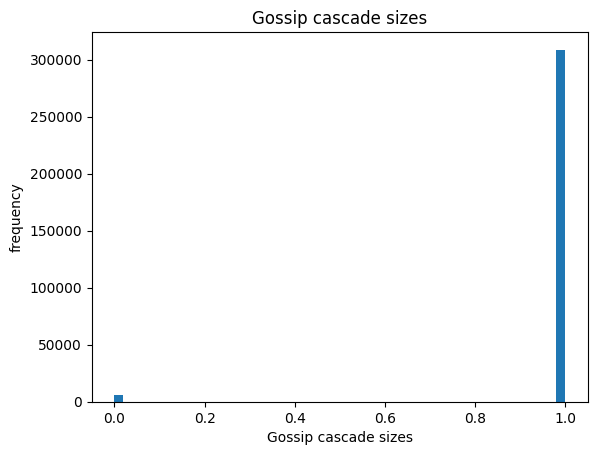

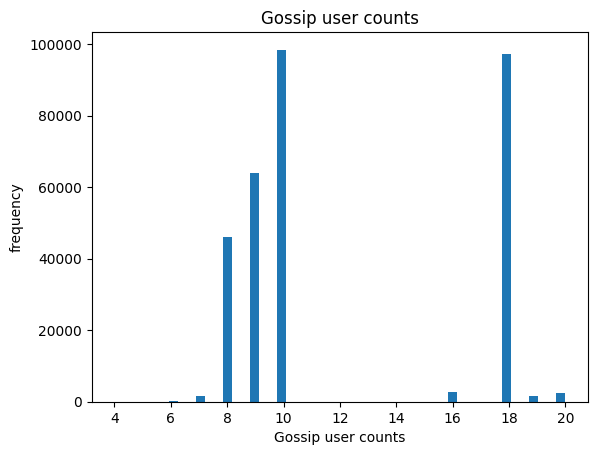

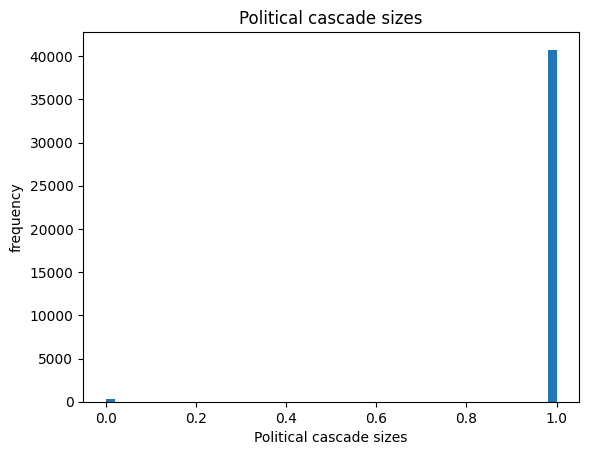

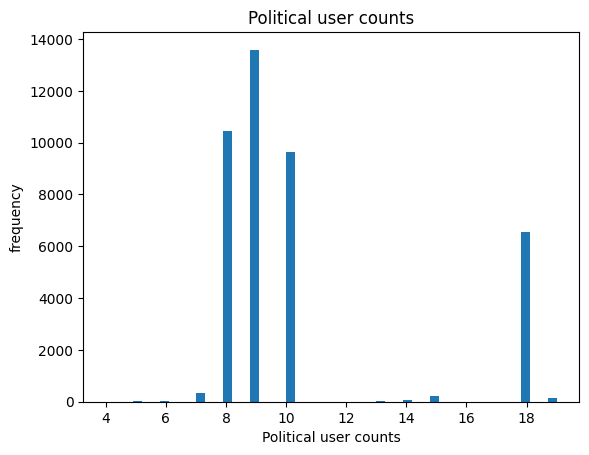

In [6]:
plot_distribution(gos_id_time_df["timestamps_count"], "Gossip cascade sizes")
plot_distribution(gos_id_twitter_df["user_ids_count"], "Gossip user counts")

plot_distribution(pol_id_time_df["timestamps_count"], "Political cascade sizes")
plot_distribution(pol_id_twitter_df["user_ids_count"], "Political user counts")

In [7]:
gossip_longest = gos_id_time_df.loc[gos_id_time_df["timestamps_count"].idxmax()]
politics_longest = pol_id_time_df.loc[pol_id_time_df["timestamps_count"].idxmax()]

print("Gossip news with longest cascade:")
print(gossip_longest)

print("\nPolitical news with longest cascade:")
print(politics_longest)

Gossip news with longest cascade:
news_id                      1
timestamps          1528805290
timestamps_count             1
Name: 1, dtype: object

Political news with longest cascade:
news_id                      1
timestamps          1231344102
timestamps_count             1
Name: 1, dtype: object


In [8]:
import pickle

with open("../data/raw/gos_id_twitter_mapping.pkl", "rb") as f:
    id_twitter_map = pickle.load(f)

# List all news node labels in the mapping
news_labels = [v for v in id_twitter_map.values() if str(v).startswith("gossipcop")]
print("Available news labels:", news_labels[:20])

Available news labels: ['gossipcop-943234', 'gossipcop-905156', 'gossipcop-924455', 'gossipcop-941695', 'gossipcop-914354', 'gossipcop-919225', 'gossipcop-850093', 'gossipcop-862425', 'gossipcop-869138', 'gossipcop-846571', 'gossipcop-941222', 'gossipcop-862499', 'gossipcop-864682', 'gossipcop-881516', 'gossipcop-938569', 'gossipcop-885398', 'gossipcop-931900', 'gossipcop-937797', 'gossipcop-938989', 'gossipcop-870602']


In [60]:
import numpy as np
import networkx as nx
import pickle
from collections import Counter

data_dir = "../data/raw/gossipcop"

# Adjacency list
edges = np.loadtxt(f"{data_dir}/A.txt", delimiter=",", dtype=int)
print(f"Loaded edges: {edges.shape}")

with open("../data/raw/gos_id_twitter_mapping.pkl", "rb") as f:
    id_twitter_map = pickle.load(f)

# Graph-level labels (0 = fake, 1 = true)
graph_labels = np.load(f"{data_dir}/graph_labels.npy")
print(f"Loaded {len(graph_labels)} news labels")

# --- Build mapping structures ---
node_to_label = id_twitter_map
label_to_node = {v: k for k, v in node_to_label.items()}

# Build graph
G = nx.Graph()
G.add_edges_from(edges)
print(f"Graph has {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

news_nodes = {nid: lbl for nid, lbl in node_to_label.items() if isinstance(lbl, str) and ("gossipcop-" in lbl or "politifact-" in lbl)}
print(f"Detected {len(news_nodes)} news nodes")

def analyze_news(news_label):
    if news_label not in label_to_node:
        print(f"News {news_label} not found in mapping.")
        return None

    news_node = label_to_node[news_label]
    if news_node >= len(graph_labels):
        print(f"No label available for {news_label}")
        return None

    label_value = graph_labels[news_node]
    label_str = "TRUE" if label_value == 1 else "FAKE"

    # Get connected users
    neighbors = list(G.neighbors(news_node))
    user_ids = []
    for n in neighbors:
        lbl = node_to_label[n]
        if lbl != news_label:  # skip self
            user_ids.append(lbl)

    user_counts = Counter(user_ids)
    print(f"News: {news_label}  →  Label: {label_str}")
    print(f"Connected users: {len(user_ids)} (unique: {len(set(user_ids))})")
    print("Top sharers:")
    for uid, cnt in user_counts.most_common(10):
        print(f"  {uid}: {cnt} times")

    return {
        "news_label": news_label,
        "truth_label": label_str,
        "user_counts": user_counts,
        "unique_users": len(set(user_ids))
    }

example_news = list(news_nodes.values())[67]

result = analyze_news(example_news)

Loaded edges: (308798, 2)
Loaded 5464 news labels
Graph has 314262 nodes, 308798 edges
Detected 5464 news nodes
News: gossipcop-864888  →  Label: TRUE
Connected users: 81 (unique: 77)
Top sharers:
  872448097330372608: 3 times
  713385903461367809: 2 times
  2157323743: 2 times
  10409622: 1 times
  2471499625: 1 times
  331528797: 1 times
  1252242577: 1 times
  3428990109: 1 times
  390457914: 1 times
  600811002: 1 times


Visualizing: gossipcop-864888


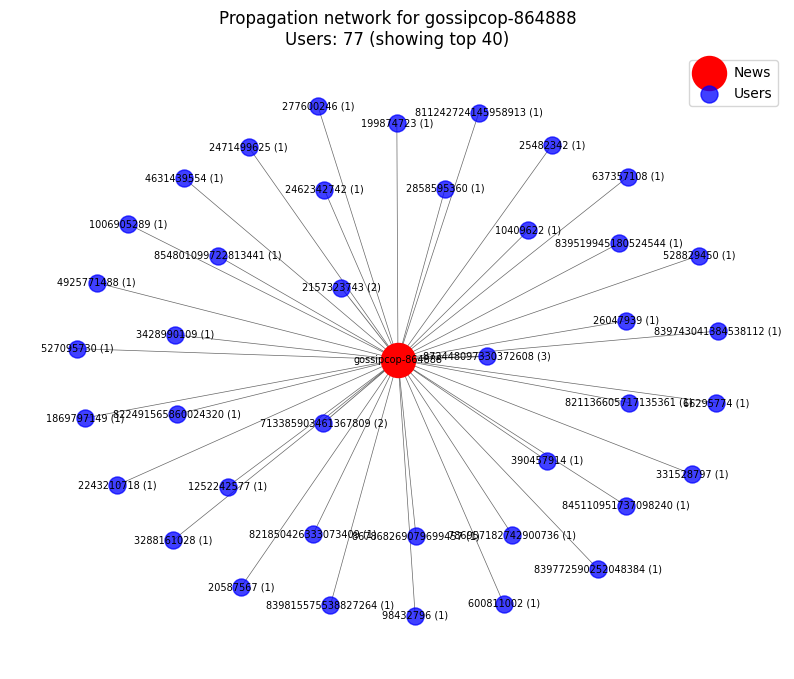

In [61]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter


def visualize_news_propagation(news_label, G, node_to_label, label_to_node, max_users=40):
    if news_label not in label_to_node:
        print(f"News {news_label} not found in mapping.")
        return

    news_node = label_to_node[news_label]
    neighbors = list(G.neighbors(news_node))

    user_ids = [node_to_label[n] for n in neighbors if node_to_label[n] != news_label]
    user_counts = Counter(user_ids)

    if not user_counts:
        print(f"No users found for news {news_label}")
        return

    # Limit to top users for readability
    top_users = dict(user_counts.most_common(max_users))

    G_sub = nx.Graph()
    G_sub.add_node(news_label, type="news")

    for uid, count in top_users.items():
        G_sub.add_node(uid, type="user", mentions=count)
        G_sub.add_edge(news_label, uid, weight=count)

    pos = nx.spring_layout(G_sub, seed=42)

    plt.figure(figsize=(10, 8))
    nx.draw_networkx_nodes(G_sub, pos, nodelist=[news_label], node_color="red", node_size=600, label="News")
    nx.draw_networkx_nodes(G_sub, pos, nodelist=top_users.keys(), node_color="blue", node_size=150, alpha=0.75, label="Users")

    widths = [max(0.5, d["weight"] * 0.3) for _, _, d in G_sub.edges(data=True)]
    nx.draw_networkx_edges(G_sub, pos, width=widths, alpha=0.6)

    labels = {news_label: news_label}
    labels.update({u: f"{u} ({cnt})" for u, cnt in top_users.items()})
    nx.draw_networkx_labels(G_sub, pos, labels=labels, font_size=7)

    plt.title(f"Propagation network for {news_label}\nUsers: {len(user_counts)} (showing top {len(top_users)})")
    plt.legend()
    plt.axis("off")
    plt.show()


print("Visualizing:", example_news)
visualize_news_propagation(example_news, G, node_to_label, label_to_node)

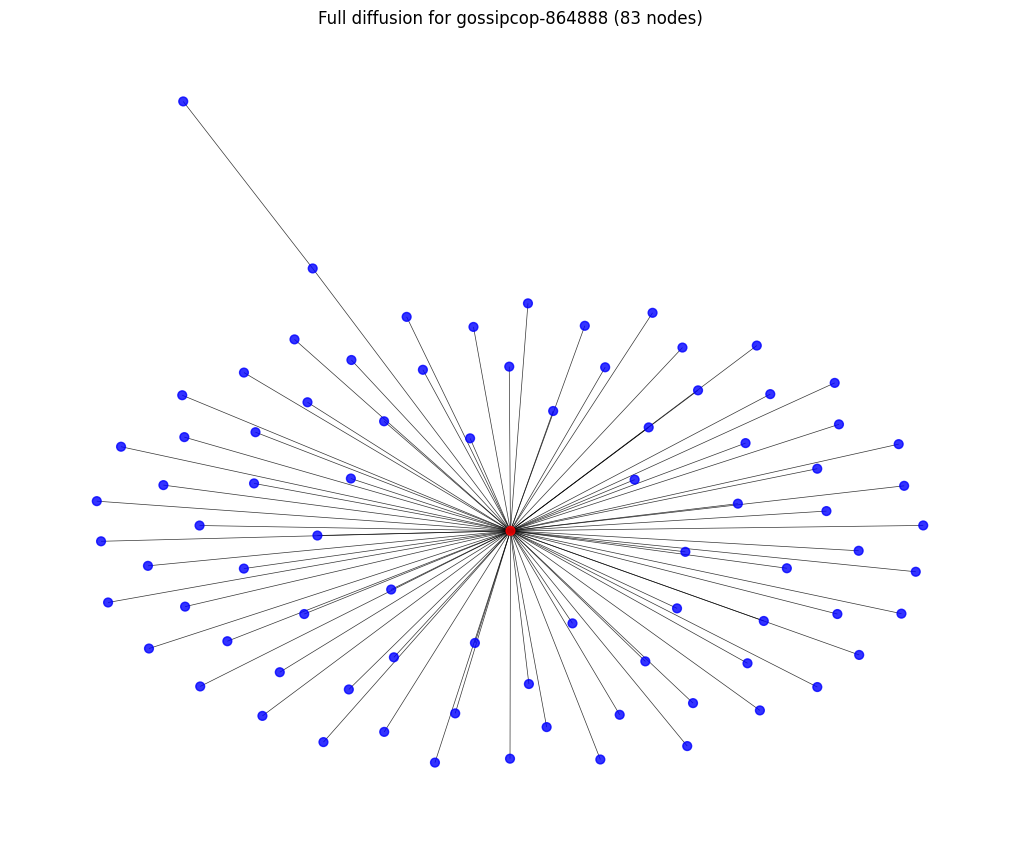

In [62]:
def get_diffusion_subgraph(news_label, G, label_to_node):
    """Return the full diffusion subgraph (multi-hop) for one news item."""
    if news_label not in label_to_node:
        raise ValueError(f"News label {news_label} not found in mapping.")

    news_node = label_to_node[news_label]
    component_nodes = nx.node_connected_component(G, news_node)
    return G.subgraph(component_nodes).copy()

def visualize_diffusion(news_label, G, node_to_label, label_to_node, max_nodes=500):
    subG = get_diffusion_subgraph(news_label, G, label_to_node)

    if subG.number_of_nodes() > max_nodes:
        print(f"Graph too large ({subG.number_of_nodes()} nodes), sampling {max_nodes}...")
        nodes_sample = set(list(subG.nodes())[:max_nodes])
        subG = subG.subgraph(nodes_sample).copy()

    node_colors = [
        "red" if node_to_label[n] == news_label else "blue"
        for n in subG.nodes()
    ]

    pos = nx.spring_layout(subG, seed=42)
    plt.figure(figsize=(10, 8))
    nx.draw(subG, pos, node_color=node_colors, node_size=40, alpha=0.8, width=0.5)
    plt.title(f"Full diffusion for {news_label} ({subG.number_of_nodes()} nodes)")
    plt.axis("off")
    plt.show()

visualize_diffusion(example_news, G, node_to_label, label_to_node)


## Description Network

Each Network is a single Piece of news, each node is a user and edges are retweets, if a user is connected to another user it means said user retweeted the news which was retweeted by the other user, i.e. Person 1 retweets News Article, Person 2 sees that Person 1 retweeted said news and retweets it themselves.

In [57]:
data_dir = Path("../data/raw/politifact").expanduser().resolve()

edges = np.genfromtxt(data_dir / "A.txt", delimiter=",", dtype=int)

degrees = Counter(edges.flatten()) 

degree_freq = Counter(degrees.values()) 

degree_freq_sorted = dict(sorted(degree_freq.items()))
print("Degree : Frequency")
for deg, freq in degree_freq_sorted.items():
    print(f"{deg} : {freq}")

labels = np.load(data_dir / "graph_labels.npy")
print("Label distribution:", Counter(labels))

Degree : Frequency
1 : 34584
2 : 3830
3 : 1021
4 : 472
5 : 226
6 : 119
7 : 91
8 : 69
9 : 62
10 : 29
11 : 27
12 : 31
13 : 25
14 : 35
15 : 17
16 : 21
17 : 15
18 : 17
19 : 7
20 : 13
21 : 14
22 : 17
23 : 10
24 : 6
25 : 7
26 : 4
27 : 5
28 : 4
29 : 7
30 : 7
31 : 9
32 : 6
33 : 1
34 : 4
35 : 6
36 : 7
37 : 6
38 : 5
39 : 5
40 : 5
42 : 3
43 : 2
44 : 5
45 : 3
46 : 5
47 : 4
48 : 5
49 : 4
50 : 3
51 : 2
52 : 2
53 : 3
54 : 2
55 : 4
57 : 4
58 : 2
60 : 1
61 : 6
62 : 1
63 : 1
64 : 3
65 : 2
66 : 3
67 : 1
68 : 3
69 : 3
70 : 1
71 : 3
74 : 1
75 : 2
76 : 3
78 : 1
79 : 7
82 : 1
83 : 1
85 : 2
86 : 1
88 : 3
89 : 1
90 : 3
91 : 1
93 : 1
94 : 2
95 : 2
96 : 2
99 : 2
100 : 1
101 : 1
102 : 1
104 : 2
106 : 1
108 : 2
109 : 1
111 : 1
113 : 1
116 : 1
117 : 1
121 : 2
122 : 2
123 : 3
124 : 2
125 : 1
126 : 1
127 : 1
129 : 3
132 : 1
134 : 2
136 : 2
137 : 2
138 : 1
141 : 1
142 : 1
143 : 1
146 : 1
151 : 1
152 : 1
154 : 1
155 : 1
156 : 2
158 : 1
162 : 1
164 : 1
165 : 2
169 : 2
170 : 2
173 : 1
180 : 1
181 : 2
182 : 1
183 : 1
184 

In [31]:
feature_files = ["new_bert_feature.npz", "new_content_feature.npz",
                 "new_profile_feature.npz", "new_spacy_feature.npz"]

for f in feature_files:
    path = data_dir / f
    X = sp.load_npz(path)
    print(f"{f}: shape {X.shape}, nnz={X.nnz}")

    data = X.data  # non-zero entries
    print(f"min={data.min()}, max={data.max()}, mean={data.mean():.4f}, std={data.std():.4f}")

for split in ["train_idx.npy", "val_idx.npy", "test_idx.npy"]:
    idx = np.load(data_dir / split)
    split_labels = labels[idx]
    print(f"{split}: {len(idx)} samples, label counts: {Counter(split_labels)}")

new_bert_feature.npz: shape (41054, 768), nnz=31529472
min=-25.066865921020508, max=1.8716731071472168, mean=-0.0288, std=0.8567
new_content_feature.npz: shape (41054, 310), nnz=12652144
min=2.1462486898826683e-08, max=1.0000001192092896, mean=0.5082, std=0.1394
new_profile_feature.npz: shape (41054, 10), nnz=328535
min=2.1462486898826683e-08, max=1.0, mean=0.1763, std=0.2770
new_spacy_feature.npz: shape (41054, 300), nnz=12316200
min=-1.6934916973114014, max=2.3819737434387207, mean=0.0013, std=0.1216
train_idx.npy: 62 samples, label counts: Counter({np.float64(0.0): 36, np.float64(1.0): 26})
val_idx.npy: 31 samples, label counts: Counter({np.float64(1.0): 18, np.float64(0.0): 13})
test_idx.npy: 221 samples, label counts: Counter({np.float64(1.0): 113, np.float64(0.0): 108})


In [32]:
for f in feature_files:
    path = data_dir / f
    try:
        X = sp.load_npz(path)
        dense = False
    except:
        X = np.load(path)
        dense = True

    print(f"--- {f} ---")
    print("Type:", "dense" if dense else "sparse (csr_matrix)")
    print("Shape:", X.shape)

    # Show first 3 rows as arrays
    if dense:
        print("Samples:\n", X[:3])
    else:
        # convert to dense for small sample
        print("Samples:\n", X[:3].toarray())

--- new_bert_feature.npz ---
Type: sparse (csr_matrix)
Shape: (41054, 768)
Samples:
 [[-0.33140707 -0.2576322   0.16209356 ...  0.40718189 -0.58252501
   0.53139174]
 [ 0.16283983 -0.02446718 -0.05698675 ...  0.40399915 -0.0832635
   0.45032552]
 [ 0.18697338  0.07173623 -0.08722332 ...  0.36749673  0.09089176
   0.4176175 ]]
--- new_content_feature.npz ---
Type: sparse (csr_matrix)
Shape: (41054, 310)
Samples:
 [[6.12447382e-01 5.50174449e-01 5.24167915e-01 6.21136549e-01
  3.57343732e-01 2.51162877e-01 6.09663685e-01 7.72607542e-01
  5.37092772e-01 7.04994974e-01 4.52733999e-01 5.57196745e-01
  5.44486284e-01 5.85030357e-01 4.35849193e-01 4.61409222e-01
  4.45603089e-01 6.88081153e-01 3.17226527e-01 5.74545395e-01
  4.46506450e-01 5.08433240e-01 6.45011375e-01 4.73072632e-01
  4.40407617e-01 5.02476739e-01 5.80305302e-01 5.38988944e-01
  2.96364653e-01 3.97797938e-01 4.11781011e-01 4.88068163e-01
  4.33994416e-01 5.57286397e-01 6.55435905e-01 5.29790061e-01
  5.71001008e-01 3.4456032